# Firm-Level Supply Chain Analysis — Tungsten 
Adaptation of Francesco's country-level framework to firm level.
Data source: synthetic firm-to-firm flows from `firm_edges.json` + `firm_nodes.json`

In [1]:
# ============================================================
# 1) LIBRARIES
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# 2) LOAD FIRM-LEVEL DATA
# ============================================================
# firm_edges.json  → SUPPLIES_TO edges (firm → firm, usd)
# firm_nodes.json  → Trader nodes (firm metadata, country_iso, volume)
# Both files were generated by main.ipynb pipeline.

data_dir = 'data'   # <<< change if files are in a different folder

with open(os.path.join(data_dir, 'firm_edges.json'), 'r') as f:
    raw_edges = json.load(f)

with open(os.path.join(data_dir, 'firm_nodes.json'), 'r') as f:
    raw_nodes = json.load(f)

# Load original COMTRADE data for validation
try:
    comtrade_raw = pd.read_json(os.path.join(data_dir, 'Cleaned_TradeData.json'))
    comtrade_exp = comtrade_raw[comtrade_raw['flowDesc'] == 'Export'].copy()
    comtrade_loaded = True
except FileNotFoundError:
    print("Warning: Cleaned_TradeData.json not found. Balance check will be skipped.")
    comtrade_loaded = False

# Build trader lookup: firm_id → node dict
trader_index = {t[':ID']: t for t in raw_nodes}

print(f'Edges loaded : {len(raw_edges)}')
print(f'Nodes loaded : {len(raw_nodes)}')
print()
print('Edge sample:')
print(pd.DataFrame(raw_edges[:3]))

Edges loaded : 5568
Nodes loaded : 192

Edge sample:
         :START_ID              :END_ID        :TYPE        kg      usd  year
0  TRADER_7a22e125      TRADER_0d33fad4  SUPPLIES_TO  0.000592   128.38  2024
1  TRADER_c5783b9d      TRADER_8368d867  SUPPLIES_TO  0.010500  3789.86  2024
2  TRADER_c5783b9d  CHN_Xiamen_Tungsten  SUPPLIES_TO  0.000880   580.72  2024


In [3]:
# ============================================================
# Value-Balance Check
# ============================================================
def check_value_balance(raw_nodes, raw_edges, comtrade_exp, comtrade_loaded):
    if not comtrade_loaded:
        return
        
    print("Running Value-Balance Check (Firm Sums vs COMTRADE Totals)...")
    node_to_country = {t[':ID']: t['country_iso'] for t in raw_nodes}
    
    # Firm based USD flows aggregated by exporter-importer pairs
    edges_df = pd.DataFrame([{
        'exp_iso': node_to_country.get(r[':START_ID']),
        'imp_iso': node_to_country.get(r[':END_ID']),
        'usd_firm': float(r['usd']) # USING RAW USD
    } for r in raw_edges])
    
    # Aggregate all synthetic firm-level trade flows by exporter-importer corridor.
    # This creates the total simulated trade value for each country pair (A → B),
    # which will later be compared against the original COMTRADE totals.
    firm_flows = edges_df.groupby(['exp_iso', 'imp_iso'])['usd_firm'].sum().reset_index()
    
    # Aggregate official COMTRADE trade values at the same bilateral corridor level.
    # These values represent the reference totals that the synthetic firm-level
    # network must reproduce in order to preserve mass balance consistency.
    ct_flows = comtrade_exp.groupby(['reporterISO', 'partnerISO'])['primaryValue'].sum().reset_index()
    ct_flows.rename(columns={'reporterISO': 'exp_iso', 'partnerISO': 'imp_iso', 'primaryValue': 'usd_ct'}, inplace=True)
    
    # Match synthetic firm-level corridor totals with the corresponding
    # COMTRADE bilateral trade values for direct consistency validation.
    balance_check = pd.merge(ct_flows, firm_flows, on=['exp_iso', 'imp_iso'], how='inner')
    
    # Compute the percentage deviation between the synthetic aggregate flows
    # and the original COMTRADE values for each exporter-importer corridor.
    balance_check['diff_pct'] = abs(balance_check['usd_firm'] - balance_check['usd_ct']) / balance_check['usd_ct'] * 100
    
    
    # Corridors with deviations above the tolerance threshold are flagged.
    # A low deviation confirms that the synthetic micro-level data preserve
    # the original macro-level trade structure (mass-balance condition).
    failed_corridors = balance_check[balance_check['diff_pct'] > 5.0]
    
    if failed_corridors.empty:
        print("✅ Value-balance check passed: Firm flows match COMTRADE totals.")
    else:
        print(f"⚠️ Discrepancy found in {len(failed_corridors)} corridors (diff > 5%).")

check_value_balance(raw_nodes, raw_edges, comtrade_exp, comtrade_loaded)

Running Value-Balance Check (Firm Sums vs COMTRADE Totals)...
✅ Value-balance check passed: Firm flows match COMTRADE totals.


=== Pareto Share Validation ===
(sum_share should be ~1.0 for each country)
country_iso  n_firms  sum_share  max_share
        AGO        1     1.0000     1.0000
        ALB        1     1.0000     1.0000
        AND        1     1.0000     1.0000
        ARE        1     1.0000     1.0000
        ARG        1     1.0000     1.0000
        ARM        1     1.0000     1.0000
        ATG        1     1.0000     1.0000
        AUS        1     1.0000     1.0000
        AUT        2     1.0000     0.5350
        AZE        1     1.0000     1.0000
        BEL        1     1.0000     1.0000
        BEN        1     1.0000     1.0000
        BFA        1     1.0000     1.0000
        BGD        1     1.0000     1.0000
        BGR        1     1.0000     1.0000
        BHR        1     1.0000     1.0000
        BHS        1     1.0000     1.0000
        BIH        1     1.0000     1.0000
        BLR        1     1.0000     1.0000
        BLZ        1     1.0000     1.0000
        BOL        1 

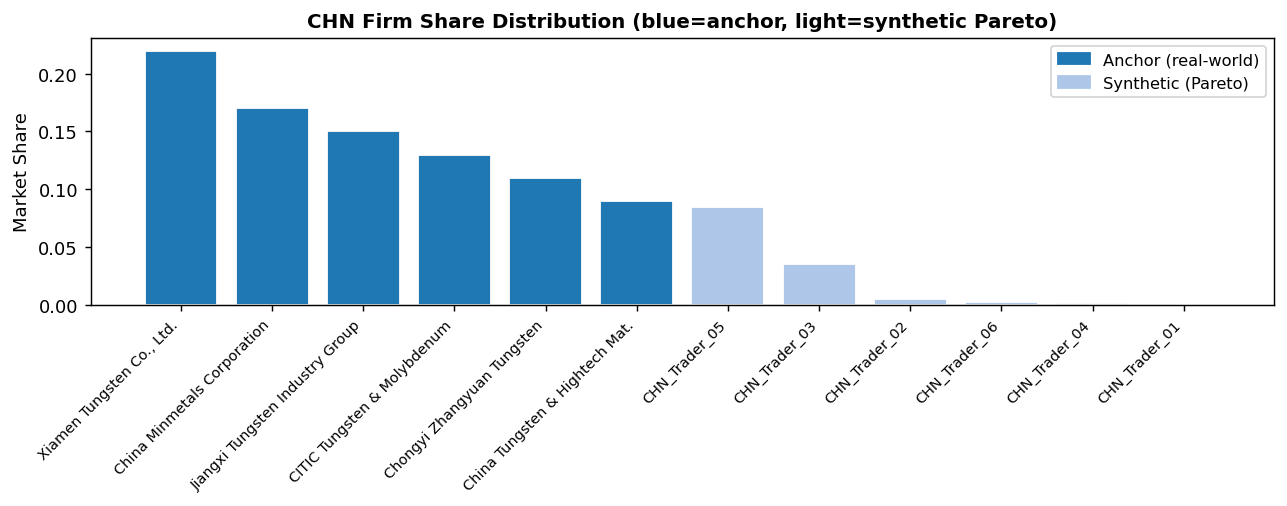

In [4]:
# ============================================================
# 2b) PARETO SHARE VALIDATION
# ============================================================
# This section explicitly documents how firm-level shares are generated.
# The synthetic firm distribution follows a Pareto law whose concentration
# parameter is calibrated using the country-level HHI, ensuring consistency
# between simulated firm concentration and empirical trade concentration.
#
# NOTE: 
# Firm shares are generated in the Python pipeline (nodes.py) BEFORE 
# exporting to JSON. They are strictly sampled from a Pareto distribution 
# whose alpha parameter is calibrated based on the country's actual HHI.
#
# In the synthetic pipeline:
#   1. For each country, an HHI is estimated from COMTRADE bilateral shares
#   2. A Pareto alpha is calibrated (via hhi.py) so that Monte Carlo
#      simulations of firm shares reproduce the observed HHI
#   3. Firm sizes are then drawn from Pareto(alpha) and normalized to sum to 1
#   4. Anchor firms (e.g. Xiamen Tungsten) get fixed shares from config.py
#   5. Remaining share is filled by synthetic traders
#
# Here we verify that firm shares per country sum to ~1.0
# and show the share distribution for key countries.

import json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_dir = 'data'
with open(os.path.join(data_dir, 'firm_nodes.json')) as f:
    raw_nodes_check = json.load(f)

nodes_df = pd.DataFrame(raw_nodes_check)
nodes_df = nodes_df.rename(columns={':ID': 'firm_id'})

# Validate that the generated firm shares form a proper probability
# distribution within each country (i.e., shares sum approximately to 1).
share_check = (
    nodes_df.groupby('country_iso')['share_pct']
            .agg(n_firms='count', sum_share='sum', max_share='max')
            .reset_index()
            .sort_values('sum_share', ascending=False)
)

print('=== Pareto Share Validation ===')
print('(sum_share should be ~1.0 for each country)')
print(share_check.to_string(index=False))

# Countries failing this condition may indicate numerical instability
# or an incorrect normalization step in the synthetic share generation.
bad = share_check[abs(share_check['sum_share'] - 1.0) > 0.02]
if len(bad) == 0:
    print('\n✅ All countries: share sums within 2% of 1.0')
else:
    print(f'\n❌ {len(bad)} countries have share sum issues:')
    print(bad.to_string(index=False))

# Plot firm size distribution for CHN (most concentrated)
chn_firms = nodes_df[nodes_df['country_iso'] == 'CHN'].sort_values('share_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4), dpi=130)
colors = ['#1F77B4' if is_anchor else '#AEC7E8'
          for is_anchor in chn_firms['is_anchor']]
ax.bar(range(len(chn_firms)), chn_firms['share_pct'], color=colors, edgecolor='white')
ax.set_xticks(range(len(chn_firms)))
ax.set_xticklabels(chn_firms['company_name'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Market Share')
ax.set_title('CHN Firm Share Distribution (blue=anchor, light=synthetic Pareto)',
             fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#1F77B4', label='Anchor (real-world)'),
    Patch(color='#AEC7E8', label='Synthetic (Pareto)')
], fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 3) PARAMETERS
# ============================================================

targetISO        = 'ITA'   # target country (all its firms are aggregated)
minEdgeUSD       = 0.0     # drop edges below this threshold (USD)
topExportPlot    = 30      # max firms shown in export chart

print('Parameters set.')

Parameters set.


In [6]:
# ============================================================
# 4) BUILD EDGE DATAFRAME
# ============================================================
# Replaced 'kg' logic with 'usd'. 

Eall = pd.DataFrame([
    {
        'source': r[':START_ID'],
        'target': r[':END_ID'],
        'usd':    float(r['usd'])   # Using economic value
    }
    for r in raw_edges
])

# Aggregate duplicates, drop non-positive
Eall = (
    Eall.groupby(['source', 'target'], as_index=False)['usd']
        .sum(min_count=1)
)
Eall['usd'] = Eall['usd'].fillna(0)
Eall = Eall[Eall['usd'] > minEdgeUSD].copy()

print(f'Edges after cleaning: {len(Eall)}')
print(f'Total flow          : ${Eall["usd"].sum():,.0f} USD')
Eall.head()

Edges after cleaning: 5568
Total flow          : $638,688,661 USD


,source,target,usd
0,CHN_CITIC_Tungsten,TRADER_0019cd75,83.85
1,CHN_CITIC_Tungsten,TRADER_05653a4a,247566.54
2,CHN_CITIC_Tungsten,TRADER_06af30f4,35.23
3,CHN_CITIC_Tungsten,TRADER_0c633074,136462.95
4,CHN_CITIC_Tungsten,TRADER_0cb5dcd6,41.21


In [7]:
# ============================================================
# 5) IDENTIFY TARGET FIRMS (ITA) AND DIRECT SUPPLIERS
# ============================================================

# All Italian firm IDs
ita_firm_ids = [
    t[':ID'] for t in raw_nodes
    if t.get('country_iso') == targetISO
]

print(f'Italian firms: {len(ita_firm_ids)}')
for fid in ita_firm_ids:
    t = trader_index[fid]
    # Changed from t/yr to USD/yr to match value-based framework
    print(f"  {fid}  |  {t['company_name']}  |  ${t['annual_volume_usd']:,.0f} USD/yr")

# Direct suppliers of ITA firms (Tier-1 equivalent)
E1_firm = Eall[Eall['target'].isin(ita_firm_ids)].copy()

# Aggregate by supplier firm
tier1_agg = (
    E1_firm.groupby('source', as_index=False)['usd']
           .sum()
           .sort_values('usd', ascending=False)
)
tier1_agg['country_iso'] = tier1_agg['source'].map(
    lambda x: trader_index.get(x, {}).get('country_iso', '?')
)
tier1_agg['company'] = tier1_agg['source'].map(
    lambda x: trader_index.get(x, {}).get('company_name', x)
)

print(f'\nDirect supplier firms (Tier-1): {len(tier1_agg)}')
print(tier1_agg[['company', 'country_iso', 'usd']].head(15).to_string(index=False))

Italian firms: 1
  TRADER_9c83edf9  |  ITA_Trader_01  |  $14,327,872 USD/yr

Direct supplier firms (Tier-1): 60
                        company country_iso        usd
                  DEU_Trader_02         DEU 2813433.77
                  BEL_Trader_01         BEL 2650454.50
                  CHE_Trader_01         CHE 1503378.85
                  DEU_Trader_03         DEU  952222.16
                  DEU_Trader_01         DEU  873690.12
                  GBR_Trader_01         GBR  765394.38
                  GBR_Trader_02         GBR  556516.66
                  FRA_Trader_01         FRA  503410.60
      Xiamen Tungsten Co., Ltd.         CHN  403434.46
                  FRA_Trader_02         FRA  322321.22
    China Minmetals Corporation         CHN  311744.81
                  CZE_Trader_01         CZE  301691.48
Jiangxi Tungsten Industry Group         CHN  275068.95
                  NLD_Trader_01         NLD  246688.58
                  IND_Trader_01         IND  241729.72


In [8]:
# ============================================================
# 6) BUILD DIRECTED GRAPH (firm × firm)
# ============================================================

g = nx.DiGraph()
for _, row in Eall.iterrows():
    # Edge weight is now USD
    g.add_edge(str(row['source']), str(row['target']), weight=float(row['usd']))

nodeNames = list(g.nodes())
N         = len(nodeNames)
idxOf     = {name: i for i, name in enumerate(nodeNames)}

print(f'Graph nodes : {N}')
print(f'Graph edges : {g.number_of_edges()}')

# W matrix: Wmat[i, j] = USD from firm i to firm j
Wmat = np.zeros((N, N), dtype=float)
for u, v, data in g.edges(data=True):
    Wmat[idxOf[u], idxOf[v]] += float(data.get('weight', 0.0))

colSum = Wmat.sum(axis=0)

# Dependency matrix P: P[i,j] = share of j's imports from i
P = np.zeros((N, N), dtype=float)
for j in range(N):
    if colSum[j] > 0:
        P[:, j] = Wmat[:, j] / colSum[j]

print(f'W matrix shape: {Wmat.shape}')
print(f'Total value flow: ${Wmat.sum():,.0f} USD')

Graph nodes : 192
Graph edges : 5568
W matrix shape: (192, 192)
Total value flow: $638,688,661 USD


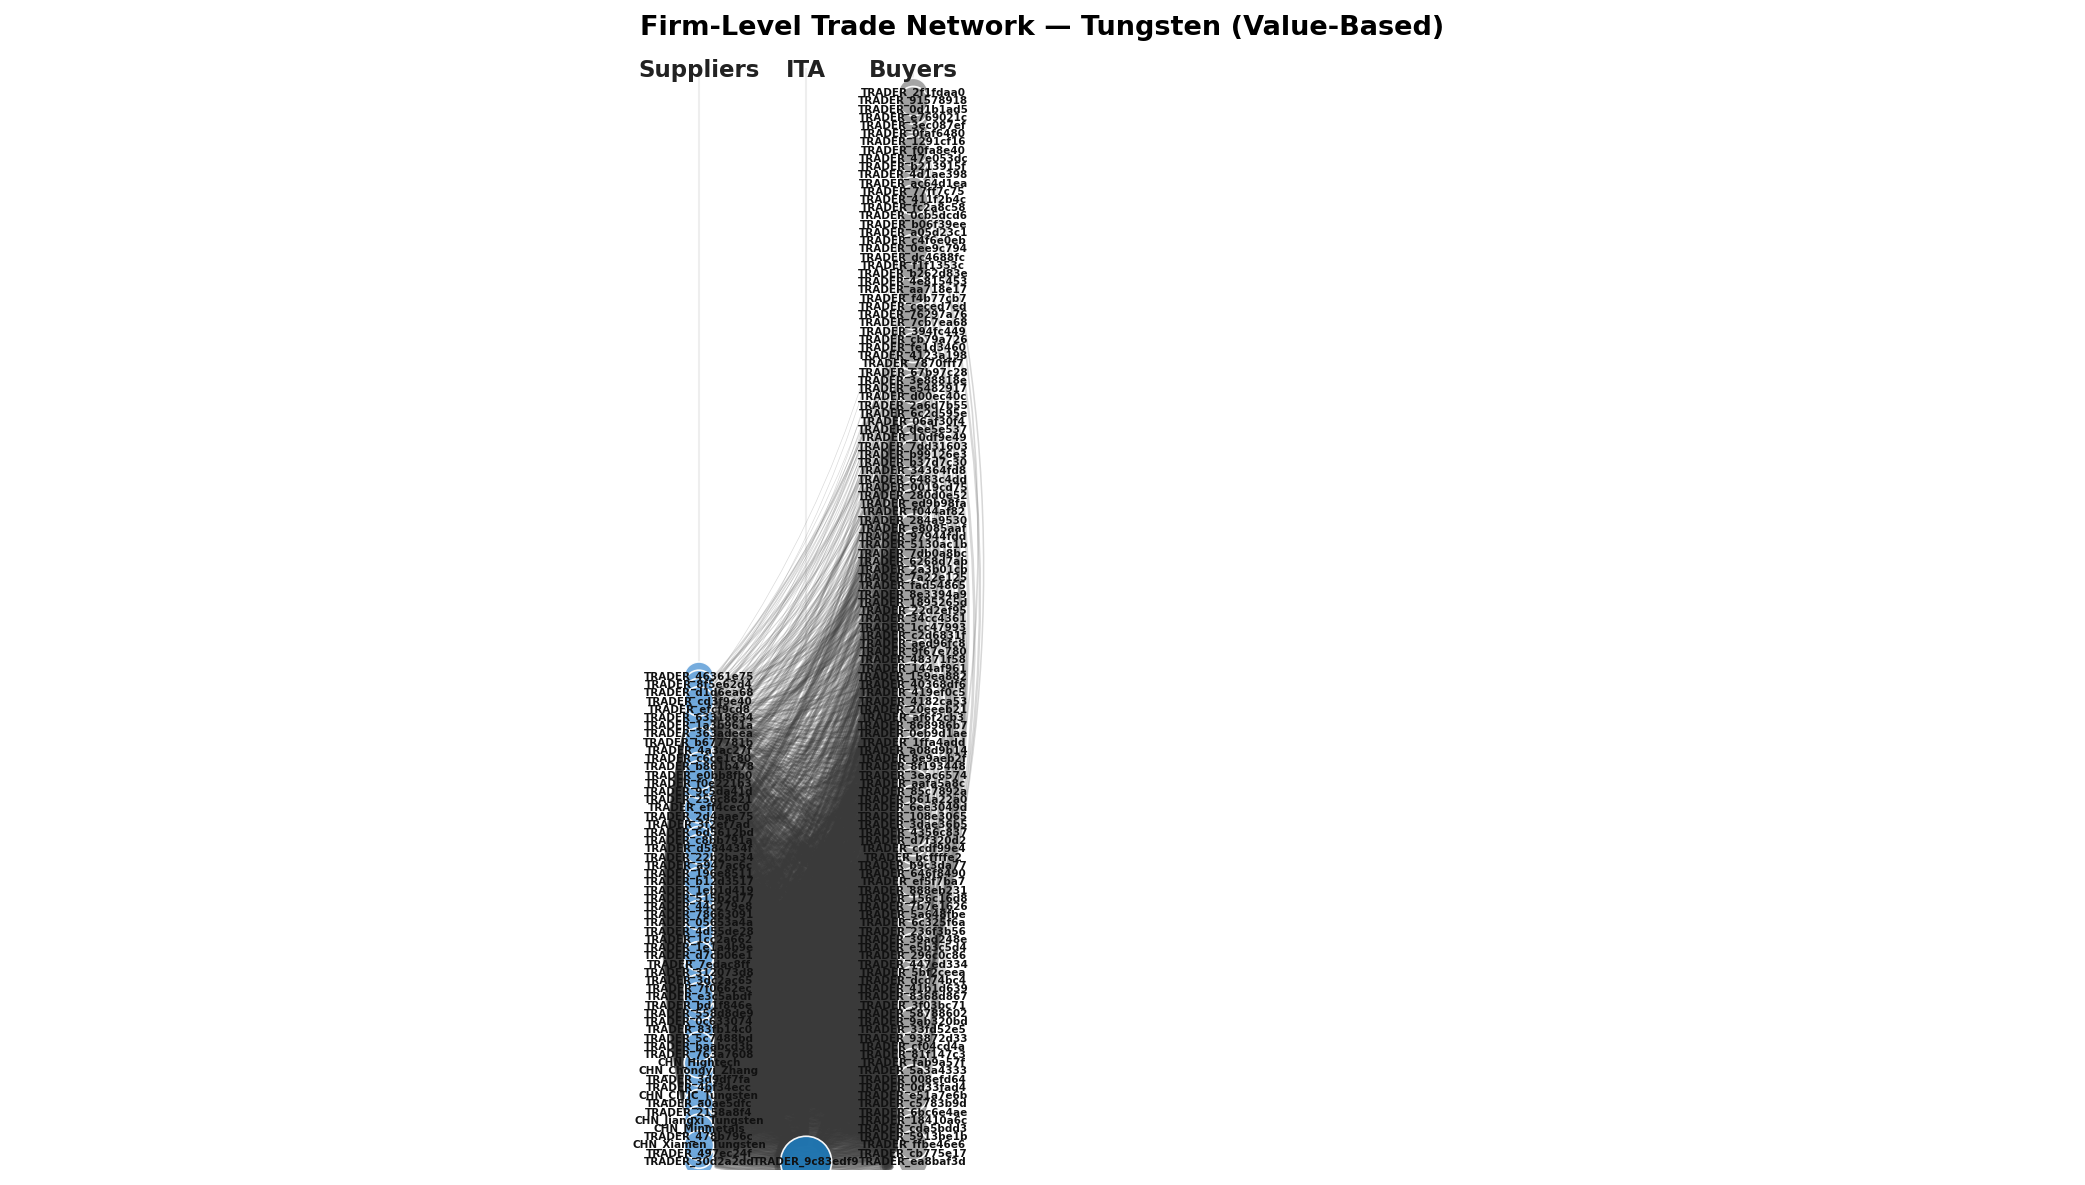

In [9]:
# ============================================================
# 7) NETWORK VISUALIZATION (firm-level)
# ============================================================
# Assign each firm a layer based on its country's role:
#   upstream suppliers → left layers
#   ITA firms          → center
#   downstream buyers  → right

# Assign layer by country (simple: ITA=2, suppliers=1, buyers=3)
def get_layer(fid):
    iso = trader_index.get(fid, {}).get('country_iso', '?')
    if iso == targetISO:
        return 2
    if fid in E1_firm['source'].values:
        return 1
    return 3

layer_map = {nd: get_layer(nd) for nd in nodeNames}

# Strength for Y ordering
strength = {}
for nd in nodeNames:
    s_in  = sum(g[u][nd]['weight'] for u in g.predecessors(nd))
    s_out = sum(g[nd][v]['weight'] for v in g.successors(nd))
    strength[nd] = s_in + s_out

x_arr = np.array([float(layer_map[nd]) for nd in nodeNames])
y_arr = np.zeros(N)
for c in np.unique(x_arr):
    idx = np.where(x_arr == c)[0]
    ordered = sorted(idx, key=lambda k: strength[nodeNames[k]], reverse=True)
    for r, k in enumerate(ordered, 1):
        y_arr[k] = r * 2.0

pos = {nodeNames[i]: (x_arr[i], y_arr[i]) for i in range(N)}

# Colors
layer_colors = {1: '#6FA8DC', 2: '#1F77B4', 3: '#A0A0A0'}
node_colors  = [layer_colors.get(int(x_arr[i]), '#CCCCCC') for i in range(N)]
node_sizes   = [600 if trader_index.get(nd, {}).get('country_iso') == targetISO else 200
                for nd in nodeNames]

# Edge widths
edges   = list(g.edges())
weights = np.array([g[u][v].get('weight', 0.0) for u, v in edges])
ww = np.log10(weights + 1.0)
if ww.max() > ww.min():
    ww = (ww - ww.min()) / (ww.max() - ww.min())
edge_widths = 0.3 + 2.5 * ww

plt.figure(figsize=(14, 8), dpi=150)
ax = plt.gca()
ax.set_axis_off()

nx.draw_networkx_edges(g, pos, width=edge_widths, edge_color='#3A3A3A',
                       alpha=0.20, arrows=True, arrowsize=8,
                       connectionstyle='arc3,rad=0.15')
nx.draw_networkx_nodes(g, pos, node_size=node_sizes, node_color=node_colors,
                       edgecolors='white', linewidths=0.8, alpha=0.95)
nx.draw_networkx_labels(g, pos, font_size=5, font_weight='bold', font_color='#111111')

col_labels = {1: 'Suppliers', 2: targetISO, 3: 'Buyers'}
topY = float(y_arr.max() + 4)
for c in np.unique(x_arr):
    ax.axvline(c, color='#EEEEEE', linewidth=1, zorder=0)
    if c in col_labels:
        plt.text(c, topY, col_labels[c], ha='center', fontsize=11,
                 fontweight='bold', color='#222222')

plt.ylim(0, topY + 2)
# Removed HS2611 to match new config
plt.title('Firm-Level Trade Network — Tungsten (Value-Based)', fontsize=13, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 8) ITA FIRM INDICES & BASELINE
# ============================================================

ita_in_graph = [f for f in ita_firm_ids if f in idxOf]
ita_indices  = [idxOf[f] for f in ita_in_graph]

baselineITA = float(Wmat[:, ita_indices].sum())
print(f'Italian firms in graph : {len(ita_in_graph)}')
print(f'Baseline ITA imports   : ${baselineITA:,.0f} USD')

if baselineITA <= 0:
    raise ValueError('Baseline ITA = 0. Check country_iso in firm_nodes.json.')

Italian firms in graph : 1
Baseline ITA imports   : $14,327,872 USD


In [11]:
# ============================================================
# 9) STRESS TEST — Firm Level
# ============================================================
# Shock: cut supply of all firms belonging to a given country.
# Same fixed-point propagation as country-level.

# --- Parameters ---
shockCountryISO = 'CHN'   # <<< country whose firms are shocked
shockFrac_val   = 0.50    # <<< fraction of supply cut (0.50 = -50%)

shockFirmIDs = [
    t[':ID'] for t in raw_nodes
    if t.get('country_iso') == shockCountryISO and t[':ID'] in idxOf
]

print(f'Shock: {shockCountryISO}  ({len(shockFirmIDs)} firms)  -{100*shockFrac_val:.0f}%')
for fid in shockFirmIDs:
    print(f"  {trader_index[fid]['company_name']}")

# --- Shock vector & multipliers ---
s = np.zeros(N, dtype=float)
for fid in shockFirmIDs:
    s[idxOf[fid]] = shockFrac_val

m = np.ones(N, dtype=float)
m[s > 0] = 1.0 - s[s > 0]

# --- Fixed-point iteration ---
maxIter, tol = 2000, 1e-8
r = np.ones(N, dtype=float)

for it in range(1, maxIter + 1):
    r_old = r.copy()
    r_new = np.ones(N, dtype=float)
    for j in range(N):
        if colSum[j] > 0:
            r_new[j] = m[j] * P[:, j].dot(r_old)
        else:
            r_new[j] = 1.0
    r = np.clip(r_new, 0.0, 1.0)
    if np.max(np.abs(r - r_old)) < tol:
        break

# --- Impact on ITA ---
postITA  = float(np.sum(Wmat[:, ita_indices] * r[:, None]))
lossUSD  = baselineITA - postITA
lossPct  = 100.0 * lossUSD / max(1e-12, baselineITA)

print('\n' + '═'*65)
print('FIRM-LEVEL STRESS TEST — Supply-side propagation (Value-Based)')
print('─'*65)
print(f'Shock country  : {shockCountryISO}  ({len(shockFirmIDs)} firms,  -{100*shockFrac_val:.0f}%)')
print('─'*65)
print(f'Baseline ITA   : ${baselineITA:,.0f} USD')
print(f'Post-shock ITA : ${postITA:,.0f} USD')
print(f'Loss ITA       : ${lossUSD:,.0f} USD  ({lossPct:.2f}%)')
print(f'Converged in   : {it} / {maxIter} iterations')
print('═'*65)

# --- Direct supplier breakdown ---
direct_sup_idx = np.where(Wmat[:, ita_indices].sum(axis=1) > 0)[0]
if len(direct_sup_idx) > 0:
    wD      = Wmat[direct_sup_idx][:, ita_indices].sum(axis=1)
    wD_post = wD * r[direct_sup_idx]
    share0 = wD / wD.sum()
    share1 = wD_post / max(wD_post.sum(), 1e-12)
    HHI0 = float(np.sum(share0**2))
    HHI1 = float(np.sum(share1**2))

    print(f'\nHHI pre-shock  : {HHI0:.4f}')
    print(f'HHI post-shock : {HHI1:.4f}')

    names_sup = [nodeNames[i] for i in direct_sup_idx]
    Tab = pd.DataFrame({
        'firm':       [trader_index.get(n, {}).get('company_name', n) for n in names_sup],
        'country':    [trader_index.get(n, {}).get('country_iso', '?') for n in names_sup],
        'usd_pre':    wD,
        'usd_post':   wD_post,
        'usd_loss':   wD - wD_post,
        'share_pre':  share0,
        'share_post': share1
    }).sort_values('usd_loss', ascending=False)

    print('\nTop loss drivers (direct suppliers of ITA):')
    Tab_show = Tab.head(15).copy()
    Tab_show['usd_pre']    = Tab_show['usd_pre'].map(lambda x: f'${x:,.0f}')
    Tab_show['usd_post']   = Tab_show['usd_post'].map(lambda x: f'${x:,.0f}')
    Tab_show['usd_loss']   = Tab_show['usd_loss'].map(lambda x: f'${x:,.0f}')
    Tab_show['share_pre']  = Tab_show['share_pre'].map(lambda x: f'{100*x:.2f}%')
    Tab_show['share_post'] = Tab_show['share_post'].map(lambda x: f'{100*x:.2f}%')
    print(Tab_show.to_string(index=False))

Shock: CHN  (12 firms)  -50%
  Xiamen Tungsten Co., Ltd.
  China Minmetals Corporation
  Jiangxi Tungsten Industry Group
  CITIC Tungsten & Molybdenum
  Chongyi Zhangyuan Tungsten
  China Tungsten & Hightech Mat.
  CHN_Trader_01
  CHN_Trader_02
  CHN_Trader_03
  CHN_Trader_04
  CHN_Trader_05
  CHN_Trader_06

═════════════════════════════════════════════════════════════════
FIRM-LEVEL STRESS TEST — Supply-side propagation (Value-Based)
─────────────────────────────────────────────────────────────────
Shock country  : CHN  (12 firms,  -50%)
─────────────────────────────────────────────────────────────────
Baseline ITA   : $14,327,872 USD
Post-shock ITA : $1 USD
Loss ITA       : $14,327,872 USD  (100.00%)
Converged in   : 131 / 2000 iterations
═════════════════════════════════════════════════════════════════

HHI pre-shock  : 0.1017
HHI post-shock : 0.1147

Top loss drivers (direct suppliers of ITA):
                           firm country    usd_pre usd_post   usd_loss share_pre share_po

In [12]:
# ============================================================
# 10) ELASTICITY — Firm Level
# ============================================================
# For each upstream firm: apply 1% shock, measure % loss in ITA imports.
# Elasticity = loss% / 1%

epsShock = 0.01
maxIter  = 2000
tol      = 1e-10

# Upstream firms: all that can reach at least one ITA firm (BFS on reversed graph)
g_rev    = g.reverse(copy=False)
upNodes  = set()
for ita_id in ita_in_graph:
    upNodes.update(nx.bfs_tree(g_rev, ita_id).nodes())
upNodes -= set(ita_in_graph)   # exclude ITA firms themselves
upIdx    = [idxOf[x] for x in upNodes if x in idxOf]

print(f'Upstream firms (can reach ITA): {len(upIdx)}')

# --- Elasticity loop ---
E       = np.full(N, np.nan, dtype=float)
iters_e = np.zeros(N, dtype=int)

for k in upIdx:
    r = np.ones(N, dtype=float)
    m = np.ones(N, dtype=float)
    m[k] = 1.0 - epsShock

    for it in range(1, maxIter + 1):
        r_old = r.copy()
        r_new = np.ones(N, dtype=float)
        for j in range(N):
            if colSum[j] > 0:
                r_new[j] = m[j] * P[:, j].dot(r_old)
            else:
                r_new[j] = 1.0
        r = np.clip(r_new, 0.0, 1.0)
        if np.max(np.abs(r - r_old)) < tol:
            iters_e[k] = it
            break
        if it == maxIter:
            iters_e[k] = maxIter

    postITA_k = float(np.sum(Wmat[:, ita_indices] * r[:, None]))
    loss_k    = (baselineITA - postITA_k) / baselineITA
    E[k]      = loss_k / epsShock

# --- Results table ---
TabE = pd.DataFrame({
    'firm_id':     nodeNames,
    'company':     [trader_index.get(nd, {}).get('company_name', nd) for nd in nodeNames],
    'country_iso': [trader_index.get(nd, {}).get('country_iso', '?') for nd in nodeNames],
    'elasticity':  E,
    'iters':       iters_e
})

TabE = TabE[TabE['firm_id'].isin(upNodes)]
TabE = TabE.dropna(subset=['elasticity'])
TabE = TabE[TabE['elasticity'] > 0.0001]
TabE = TabE.sort_values('elasticity', ascending=False)

print('\n=== FIRM-LEVEL ELASTICITY (1% shock) — ITA target ===')
print('(firms with elasticity > 0.0001)')
TabE_show = TabE.head(30).copy()
TabE_show['elasticity'] = TabE_show['elasticity'].map(lambda x: f'{x:.4f}')
TabE_show['iters']      = TabE_show['iters'].map(lambda x: f'{int(x)}')
print(TabE_show[['company','country_iso','elasticity','iters']].to_string(index=False))
print('\nNote: elasticity = % ITA import VALUE loss per 1% supply cut of that firm.')

Upstream firms (can reach ITA): 94

=== FIRM-LEVEL ELASTICITY (1% shock) — ITA target ===
(firms with elasticity > 0.0001)
                        company country_iso elasticity iters
                  JPN_Trader_05         JPN    96.6800  2000
                  MYS_Trader_01         MYS    95.3776  2000
                  BRN_Trader_01         BRN    90.6210  2000
      Xiamen Tungsten Co., Ltd.         CHN    67.3921  2000
                  MYS_Trader_02         MYS    58.9927  2000
    China Minmetals Corporation         CHN    57.9325  2000
Jiangxi Tungsten Industry Group         CHN    53.4205  2000
    CITIC Tungsten & Molybdenum         CHN    48.4249  2000
     Chongyi Zhangyuan Tungsten         CHN    42.8937  2000
 China Tungsten & Hightech Mat.         CHN    36.7694  2000
                  POL_Trader_01         POL    36.0578  2000
                  CHN_Trader_05         CHN    35.0399  2000
                  DEU_Trader_02         DEU    32.7286  2000
                  CZE_T

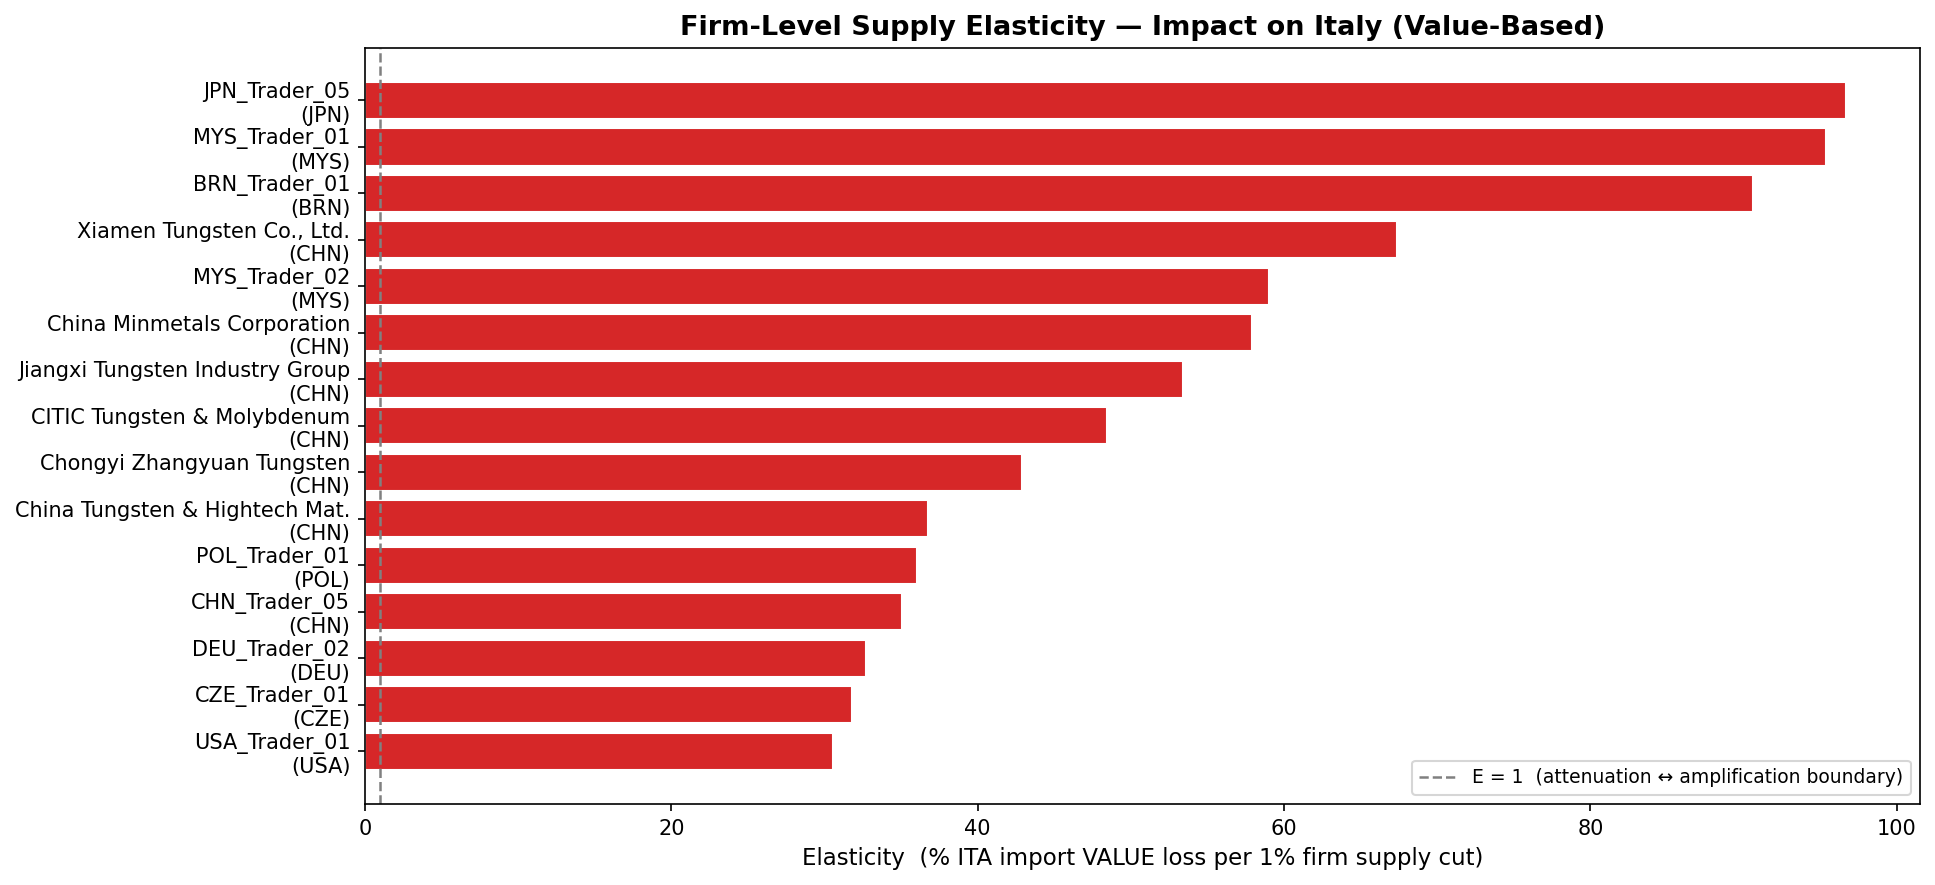

In [13]:
# ============================================================
# 11) BAR CHART — Top Firms by Elasticity
# ============================================================

top = TabE.head(15).copy()
top['elasticity'] = top['elasticity'].astype(float)
top['label'] = top.apply(
    lambda r: f"{r['company']}\n({r['country_iso']})", axis=1
)

colors = ['#D62728' if e >= 1 else '#1F77B4' for e in top['elasticity']]

fig, ax = plt.subplots(figsize=(13, 6), dpi=150)
ax.barh(top['label'][::-1], top['elasticity'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(1.0, color='gray', linewidth=1.2, linestyle='--',
           label='E = 1  (attenuation ↔ amplification boundary)')
ax.set_xlabel('Elasticity  (% ITA import VALUE loss per 1% firm supply cut)', fontsize=11)
ax.set_title('Firm-Level Supply Elasticity — Impact on Italy (Value-Based)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()